# DATA CLEANING , DATA TRANSFORMATION, DATA MODELLING

In [1]:
import os
import pandas as pd

folder_path = r"C:\Users\suren\Downloads\data"

data_dict = {}

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(folder_path, file))
        name = file.replace(".csv", "")
        data_dict[name] = df

# assign variables
purchases = data_dict["purchases"]
purchase_prices = data_dict["purchase_prices"]
sales = data_dict["sales"]
vendor_invoice = data_dict["vendor_invoice"]

In [2]:
# Fix VendorNo → VendorNumber
sales.rename(columns={"VendorNo": "VendorNumber"}, inplace=True)

In [3]:
def build_vendor_sales_summary(purchases, purchase_prices, sales, vendor_invoice):

    # 🔹 remove duplicate columns from prices to avoid _x, _y issue
    # 🔹 remove duplicate columns BEFORE merge
    purchase_prices = purchase_prices.drop(
        columns=["VendorNumber", "VendorName", "PurchasePrice"],
        errors="ignore"
    )
    
    # 🔹 merge
    purchases_merged = purchases.merge(
        purchase_prices,
        on=["Brand", "Description"],
        how="left"
    )

    # 🔹 purchase summary
    ps = purchases_merged.groupby(
        ["VendorNumber", "VendorName", "Brand", "Description", "PurchasePrice", "Price", "Volume"],
        as_index=False
    ).agg({
        "Quantity": "sum",
        "Dollars": "sum"
    }).rename(columns={
        "Quantity": "TotalPurchaseQuantity",
        "Dollars": "TotalPurchaseDollars",
        "Price": "ActualPrice"
    })

    # 🔹 sales summary
    ss = sales.groupby(
        ["VendorNumber", "Brand"],
        as_index=False
    ).agg({
        "SalesQuantity": "sum",
        "SalesDollars": "sum",
        "SalesPrice": "sum",
        "ExciseTax": "sum"
    }).rename(columns={
        "SalesQuantity": "TotalSalesQuantity",
        "SalesDollars": "TotalSalesDollars",
        "SalesPrice": "TotalSalesPrice",
        "ExciseTax": "TotalExciseTax"
    })

    # 🔹 freight summary
    fs = vendor_invoice.groupby(
        "VendorNumber", as_index=False
    )["Freight"].sum().rename(columns={
        "Freight": "FreightCost"
    })

    # 🔹 merge all
    final_df = ps.merge(
        ss,
        on=["VendorNumber", "Brand"],
        how="left"
    )

    final_df = final_df.merge(
        fs,
        on="VendorNumber",
        how="left"
    )

    # 🔹 select columns
    final_df = final_df[[
        "VendorNumber",
        "VendorName",
        "Brand",
        "Description",
        "PurchasePrice",
        "ActualPrice",
        "Volume",
        "TotalPurchaseQuantity",
        "TotalPurchaseDollars",
        "TotalSalesQuantity",
        "TotalSalesDollars",
        "TotalSalesPrice",
        "TotalExciseTax",
        "FreightCost"
    ]]

    # 🔹 add profit
    final_df["Profit"] = final_df["TotalSalesDollars"] - final_df["TotalPurchaseDollars"]

    return final_df

In [4]:
final_df = build_vendor_sales_summary(
    purchases,
    purchase_prices,
    sales,
    vendor_invoice
)

In [5]:
print(final_df.shape)
print(final_df.head())

(10693, 15)
   VendorNumber                               VendorName  Brand  \
0             2  IRA GOLDMAN AND WILLIAMS, LLP            90085   
1             2  IRA GOLDMAN AND WILLIAMS, LLP            90609   
2            54              AAPER ALCOHOL & CHEMICAL CO    990   
3            60              ADAMBA IMPORTS INTL INC        771   
4            60              ADAMBA IMPORTS INTL INC       3401   

                    Description  PurchasePrice  ActualPrice Volume  \
0  Ch Lilian 09 Ladouys St Este          23.86        36.99    750   
1  Flavor Essence Variety 5 Pak          17.00        24.99  162.5   
2       Ethyl Alcohol 200 Proof         105.07       134.49   3750   
3   Bak's Krupnik Honey Liqueur          11.44        14.99    750   
4                  Vesica Vodka          11.10        14.99   1750   

   TotalPurchaseQuantity  TotalPurchaseDollars  TotalSalesQuantity  \
0                      8                190.88                18.0   
1                    320

In [6]:
final_df.isnull().sum()

VendorNumber               0
VendorName                 0
Brand                      0
Description                0
PurchasePrice              0
ActualPrice                0
Volume                     0
TotalPurchaseQuantity      0
TotalPurchaseDollars       0
TotalSalesQuantity       178
TotalSalesDollars        178
TotalSalesPrice          178
TotalExciseTax           178
FreightCost                0
Profit                   178
dtype: int64

In [7]:
cols_to_fill = [
    "TotalSalesQuantity",
    "TotalSalesDollars",
    "TotalSalesPrice",
    "TotalExciseTax"
]

final_df[cols_to_fill] = final_df[cols_to_fill].fillna(0)

# Recalculate profit
final_df["Profit"] = final_df["TotalSalesDollars"] - final_df["TotalPurchaseDollars"]

In [8]:
final_df.duplicated().sum()

np.int64(0)

In [9]:
final_df[final_df["VendorNumber"] == final_df["VendorNumber"].iloc[0]]

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,Profit
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750,8,190.88,18.0,665.82,295.92,2.00,27.08,474.94
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,17.00,24.99,162.5,320,5440.00,24.0,599.76,449.82,0.52,27.08,-4840.24


In [10]:
print("Final rows:", len(final_df))
print("Unique vendors:", final_df["VendorNumber"].nunique())

Final rows: 10693
Unique vendors: 126


In [11]:
final_df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,Profit
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750,8,190.88,18.0,665.82,295.92,2.00,27.08,474.94
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,17.00,24.99,162.5,320,5440.00,24.0,599.76,449.82,0.52,27.08,-4840.24
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,105.07,134.49,3750,1,105.07,0.0,0.00,0.00,0.00,0.48,-105.07
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750,39,446.16,47.0,704.53,494.67,37.01,367.52,258.37
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,11.10,14.99,1750,6,66.60,0.0,0.00,0.00,0.00,367.52,-66.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10688,173357,TAMWORTH DISTILLING,2804,Camp Robber Whiskey,32.14,44.99,750,210,6749.40,140.0,6298.60,3194.29,110.33,202.50,-450.80
10689,173357,TAMWORTH DISTILLING,3666,Art in the Age Chicory Root,18.79,24.99,375,520,9770.80,360.0,8996.40,4873.05,141.19,202.50,-774.40
10690,173357,TAMWORTH DISTILLING,3848,Chicory Root Vodka,23.30,30.99,750,28,652.40,6.0,185.94,92.97,4.71,202.50,-466.46
10691,173357,TAMWORTH DISTILLING,3909,White Mountain Vodka,19.37,24.99,750,1232,23863.84,982.0,24540.18,14469.21,773.87,202.50,676.34


In [12]:
final_df.dtypes

VendorNumber               int64
VendorName                object
Brand                      int64
Description               object
PurchasePrice            float64
ActualPrice              float64
Volume                    object
TotalPurchaseQuantity      int64
TotalPurchaseDollars     float64
TotalSalesQuantity       float64
TotalSalesDollars        float64
TotalSalesPrice          float64
TotalExciseTax           float64
FreightCost              float64
Profit                   float64
dtype: object

In [13]:
final_df["VendorName"].unique()

array(['IRA GOLDMAN AND WILLIAMS, LLP          ',
       'AAPER ALCOHOL & CHEMICAL CO', 'ADAMBA IMPORTS INTL INC    ',
       'ALTAMAR BRANDS LLC         ', 'AMERICAN SPIRITS EXCHANGE  ',
       'APPOLO VINEYARDS LLC       ', 'ATLANTIC IMPORTING COMPANY ',
       'BACARDI USA INC            ', 'BANFI PRODUCTS CORP        ',
       'STATE WINE & SPIRITS   ', 'SAZERAC NORTH AMERICA INC. ',
       'BRONCO WINE COMPANY        ', 'BROWN-FORMAN CORP          ',
       'BULLY BOY DISTILLERS       ', 'BLACK ROCK SPIRITS LLC     ',
       'CALEDONIA SPIRITS INC      ', 'CONSTELLATION BRANDS INC   ',
       'CAPSTONE INTERNATIONAL     ', 'CASTLE BRANDS CORP.        ',
       'VINEYARD BRANDS INC        ', 'VINEYARD BRANDS LLC        ',
       'DIAGEO CHATEAU ESTATE WINES', 'VRANKEN AMERICA            ',
       'Circa Wines                ', 'FABRIZIA SPIRITS LLC       ',
       'ALISA CARR BEVERAGES           ', 'SOUTHERN GLAZERS W&S OF NE ',
       'SOUTHERN WINE & SPIRITS NE ', 'DELICATO VINEY

In [14]:
final_df['Description'].unique()

array(['Ch Lilian 09 Ladouys St Este', 'Flavor Essence Variety 5 Pak',
       'Ethyl Alcohol 200 Proof', ..., 'Art in the Age Chicory Root',
       'Chicory Root Vodka', 'White Mountain Vodka'], dtype=object)

In [15]:
final_df["Volume"]=final_df["Volume"].astype('float64')

In [16]:
final_df["VendorName"]=final_df["VendorName"].str.strip()

In [17]:
final_df.rename(columns={"Profit": "GrossProfit"}, inplace=True)

In [18]:
final_df['ProfitMargin'] = (final_df['GrossProfit']/final_df['TotalSalesDollars'])*100

In [19]:
final_df['StockTurnover'] = final_df['TotalSalesQuantity']/final_df['TotalPurchaseQuantity']

In [20]:
final_df['SalesPurchaseRatio'] = final_df['TotalSalesDollars']/final_df['TotalPurchaseDollars']

In [21]:
pip install pyodbc sqlalchemy

In [22]:
from sqlalchemy import create_engine

server = 'Surendra_Reddy'   # e.g., 'DESKTOP-XXXX\SQLEXPRESS'
database = 'InventorySales'

connection_string = f"mssql+pyodbc://@{server}/{database}?driver=ODBC+Driver+17+for+SQL+Server"

engine = create_engine(connection_string)

In [23]:
import numpy as np

final_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [24]:
float_cols = final_df.select_dtypes(include=["float64"]).columns

final_df[float_cols] = final_df[float_cols].round(2)

In [25]:
final_df = final_df.where(pd.notnull(final_df), None)

In [26]:
final_df.to_sql(
    name="vendor_sales_summary",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=1000
)

833

In [27]:
final_df.to_csv("final_dataset.csv", index=False)

In [28]:
import os
print(os.getcwd())

C:\Users\suren


In [29]:
final_df.to_csv(r"C:\Users\suren\Downloads\final_dataset.csv", index=False)

In [30]:
import pandas as pd

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
import scipy.stats as stats


In [32]:
df=pd.read_sql_query("select * from vendor_sales_summary",connection_string)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750.0,8,190.88,18.0,665.82,295.92,2.00,27.08,474.94,71.33,2.25,3.49
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,17.00,24.99,162.5,320,5440.00,24.0,599.76,449.82,0.52,27.08,-4840.24,-807.03,0.08,0.11
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,105.07,134.49,3750.0,1,105.07,0.0,0.00,0.00,0.00,0.48,-105.07,NaN,0.00,0.00
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750.0,39,446.16,47.0,704.53,494.67,37.01,367.52,258.37,36.67,1.21,1.58
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,11.10,14.99,1750.0,6,66.60,0.0,0.00,0.00,0.00,367.52,-66.60,NaN,0.00,0.00


In [33]:
#summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10693.0,10649.892921,18752.805318,2.00,3951.00,7153.00,9552.00,201359.00
Brand,10693.0,18037.744319,12662.525384,58.00,5789.00,18761.00,25514.00,90631.00
PurchasePrice,10693.0,24.383023,109.264519,0.00,6.84,10.45,19.47,5681.81
ActualPrice,10693.0,35.640338,148.239484,0.00,10.99,15.99,28.99,7499.99
Volume,10693.0,847.351445,664.278813,50.00,750.00,750.00,750.00,20000.00
TotalPurchaseQuantity,10693.0,3140.781539,11094.573249,1.00,36.00,262.00,1978.00,337660.00
TotalPurchaseDollars,10693.0,30103.877820,123062.388765,0.00,453.18,3655.23,20733.42,3811251.60
TotalSalesQuantity,10693.0,3077.356308,10952.346909,0.00,33.00,261.00,1929.00,334939.00
TotalSalesDollars,10693.0,42244.312108,167648.300465,0.00,729.27,5298.21,28406.05,5101919.51
TotalSalesPrice,10693.0,18797.686610,44952.483000,0.00,289.71,2857.80,16075.38,672819.31


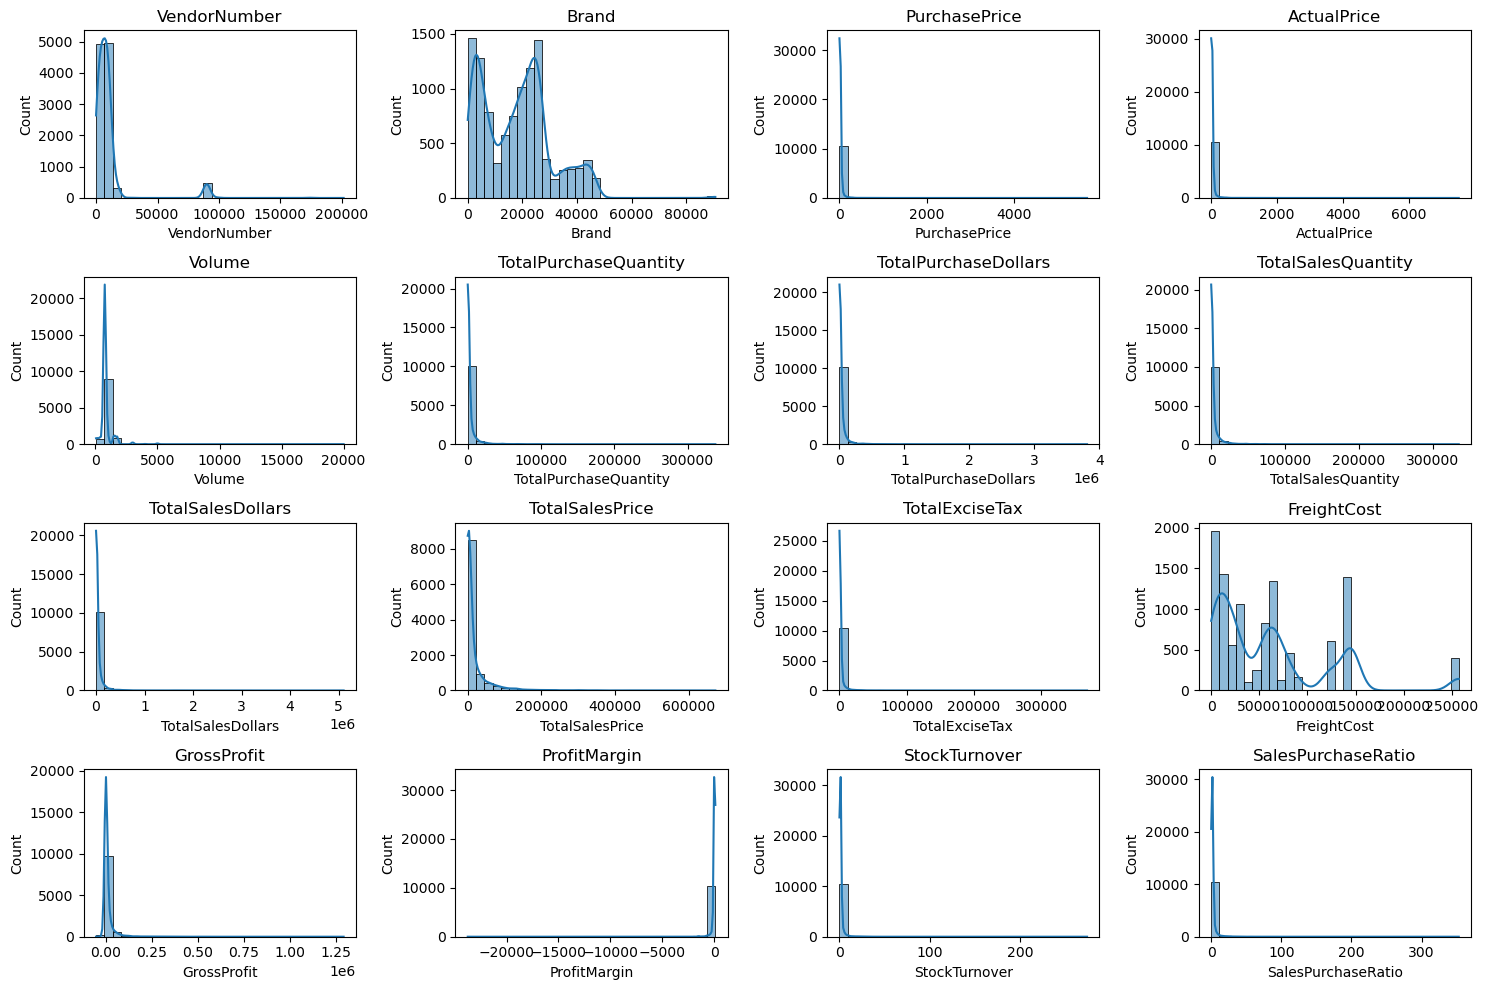

In [34]:
#distribution plots for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()
    

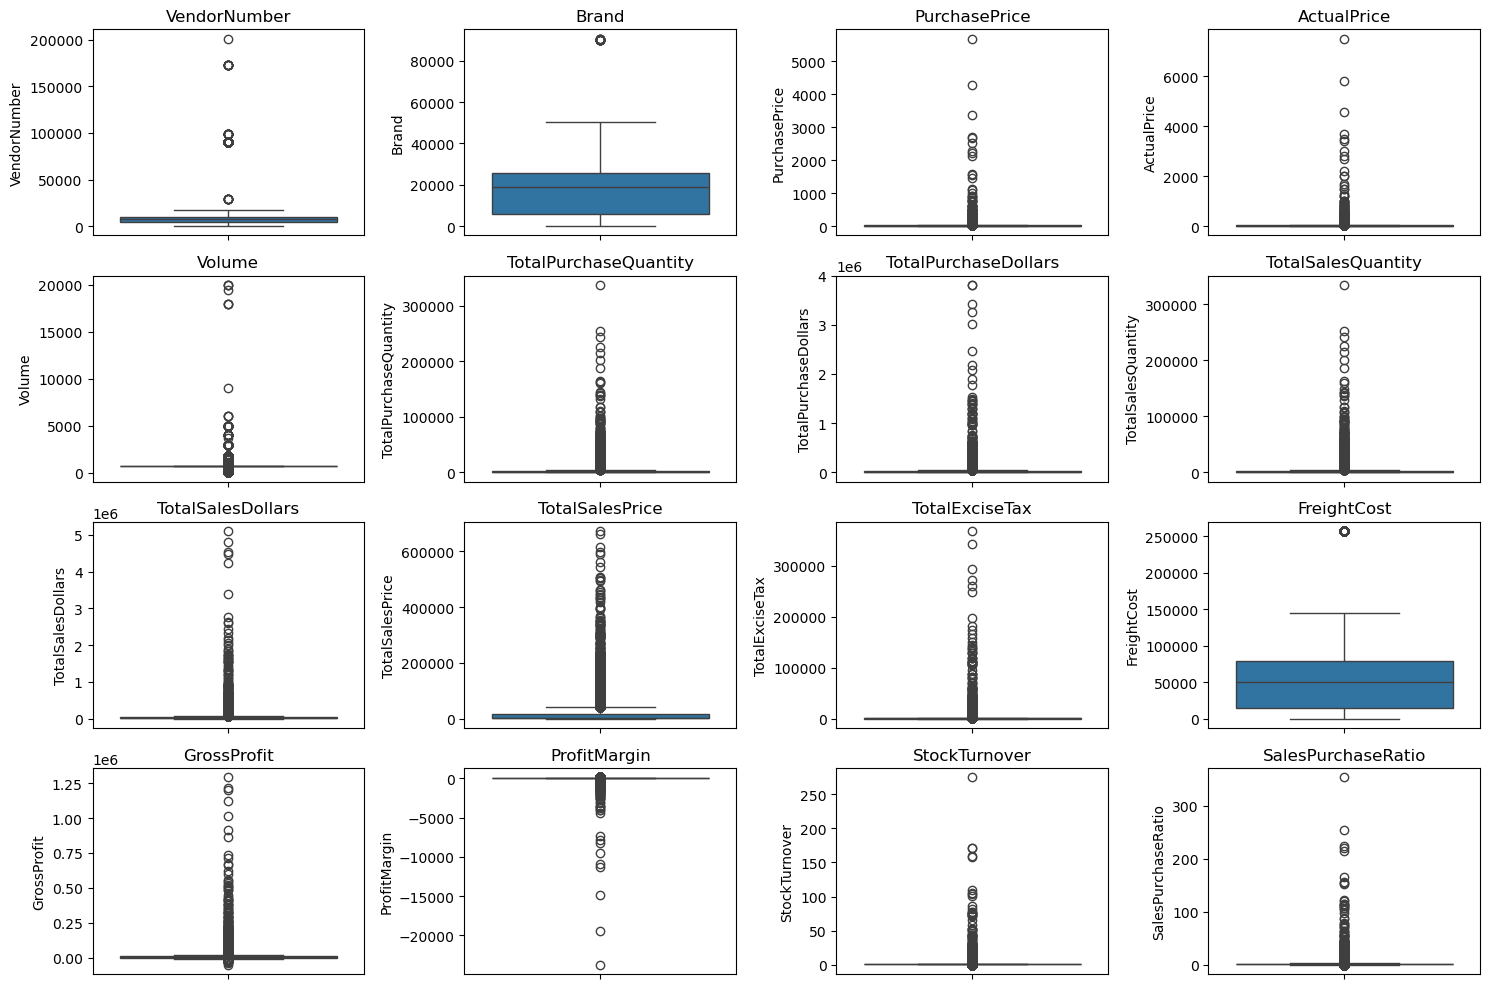

In [35]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# Summary Statistics Insights:
 Negative & Zero Values:
- Gross profit : Minimum value is -52002.78, indicating losses. Some products or transactions may be selling at a loss due to selling at high costs or selling at discounts lowerthan the purchase price.
- Profit Margin : Has a Minimum of -23730.64, which suggests the revenue is lower than costs.
- Total Sales Quantity & Sales Dollars : Minimum values are 0, meaning some products were purchased but never sold. Thease could be slow moving or obsolete stock.

 Outliers Indicated by High Standard Deviations:
- Purchase & Actual Prices : The max values (5681.81,7499.99) are significantly higher than the mean(24.38,35.64) indicating potential premium products.
- Freight Cost : Huge variation, from 0.09 to 257032.07, suggests logistics inefficiencies or bulk shipments.
- Stock Turnover : Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for the product is higher than purchased quantity due to either sales are being fulfilled from older stock

In [36]:
#filter the data by removing inconsistencies
df = pd.read_sql_query(""" SELECT * from vendor_sales_summary
where GrossProfit>0
AND ProfitMargin>0
AND TotalSalesQuantity>0""",connection_string)

In [37]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,750.0,8,190.88,18.0,665.82,295.92,2.00,27.08,474.94,71.33,2.25,3.49
1,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,750.0,39,446.16,47.0,704.53,494.67,37.01,367.52,258.37,36.67,1.21,1.58
2,105,ALTAMAR BRANDS LLC,2529,Right Gin,23.25,29.99,750.0,12,279.00,12.0,359.88,59.98,9.44,62.39,80.88,22.47,1.00,1.29
3,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,750.0,320,11427.20,307.0,15346.93,12947.41,242.15,62.39,3919.73,25.54,0.96,1.34
4,200,AMERICAN SPIRITS EXCHANGE,20789,Zin-phomaniac Znfdl,9.73,14.99,750.0,96,934.08,84.0,1511.16,287.84,9.43,6.19,577.08,38.19,0.88,1.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,172662,SWEETWATER FARM,2191,Clark & Chesterfield Whiskey,14.70,19.99,375.0,138,2028.60,125.0,2498.75,1819.09,49.00,178.34,470.15,18.82,0.91,1.23
8561,172662,SWEETWATER FARM,2265,Monadnock Moonshine,21.47,28.99,750.0,267,5732.49,222.0,6435.78,5363.15,175.13,178.34,703.29,10.93,0.83,1.12
8562,172662,SWEETWATER FARM,3632,Ashuelot Vodka,21.58,28.49,750.0,554,11955.32,452.0,12877.48,8205.12,356.14,178.34,922.16,7.16,0.82,1.08
8563,173357,TAMWORTH DISTILLING,3909,White Mountain Vodka,19.37,24.99,750.0,1232,23863.84,982.0,24540.18,14469.21,773.87,202.50,676.34,2.76,0.80,1.03


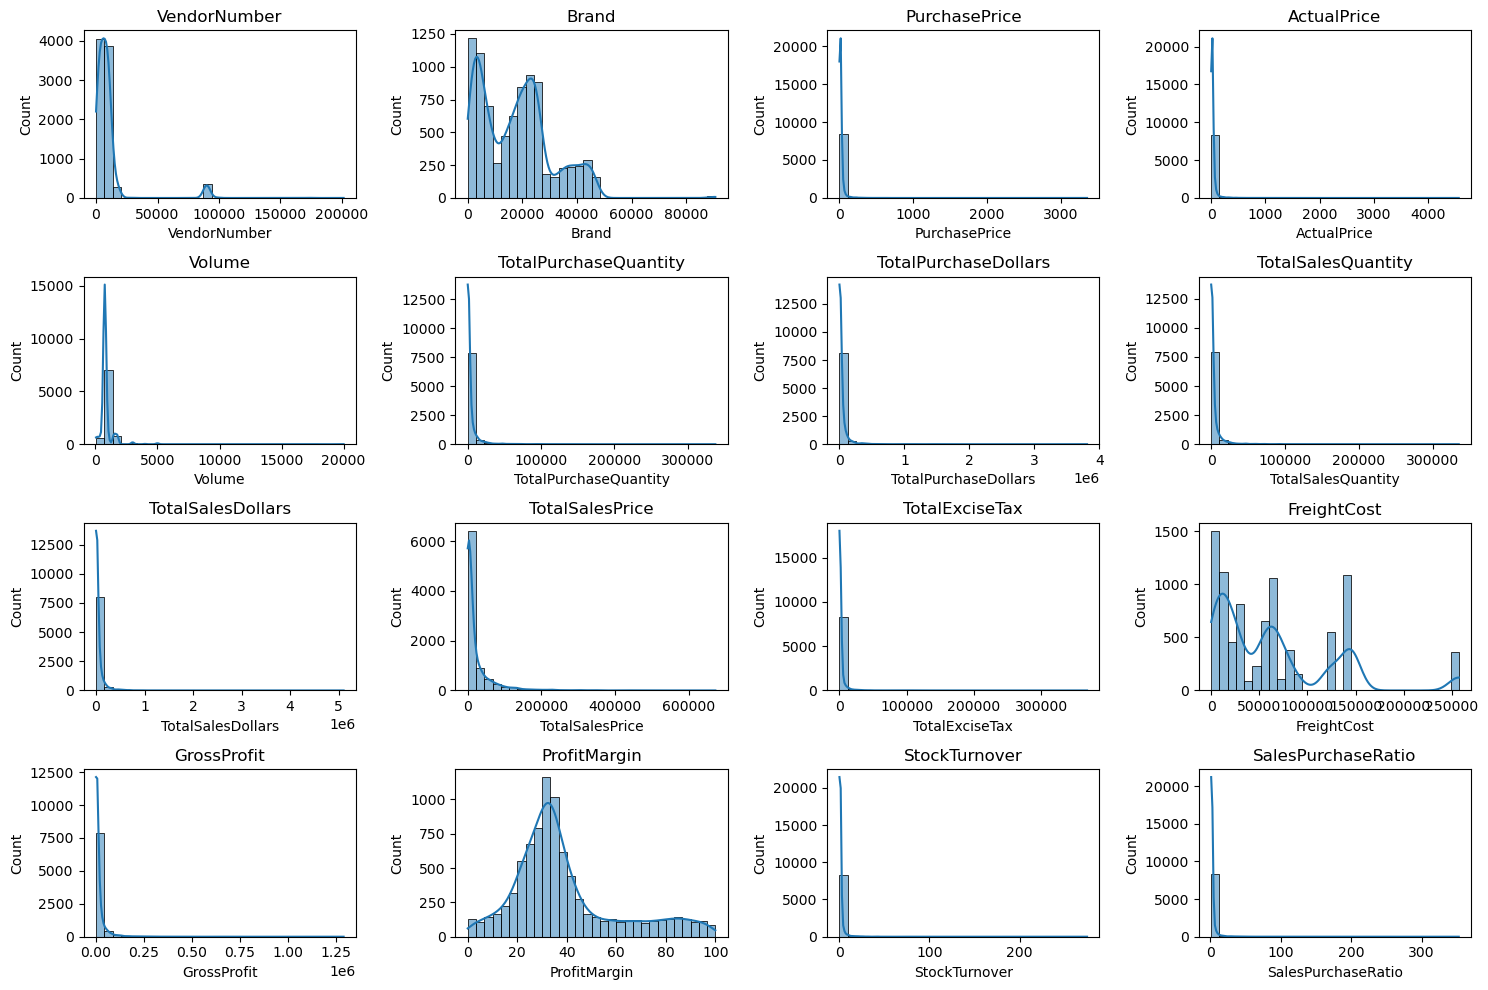

In [38]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()
    

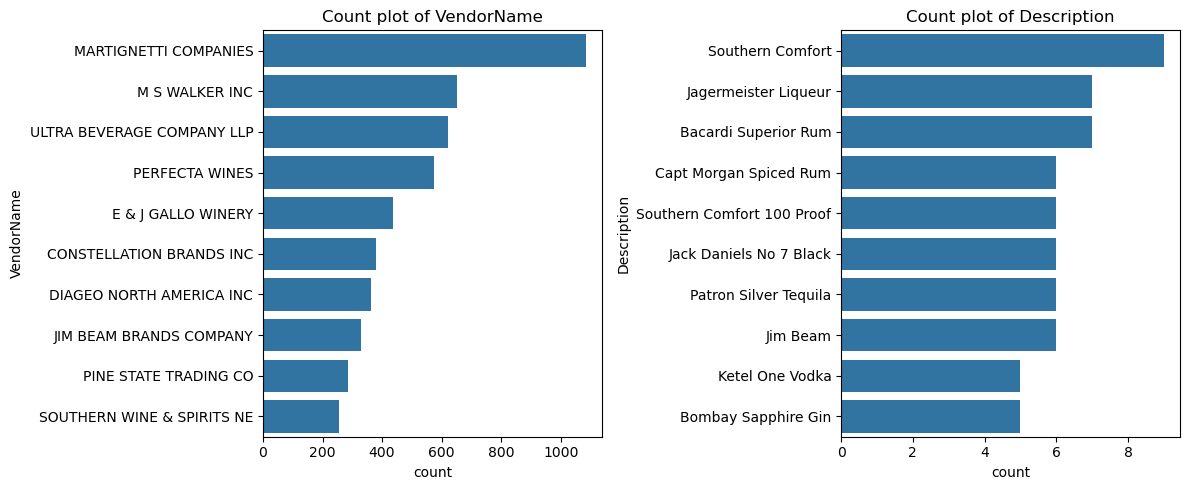

In [39]:
# Count plots for categorical columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12,5))
for i,col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10])
    plt.title(f"Count plot of {col}")
plt.tight_layout()
plt.show()


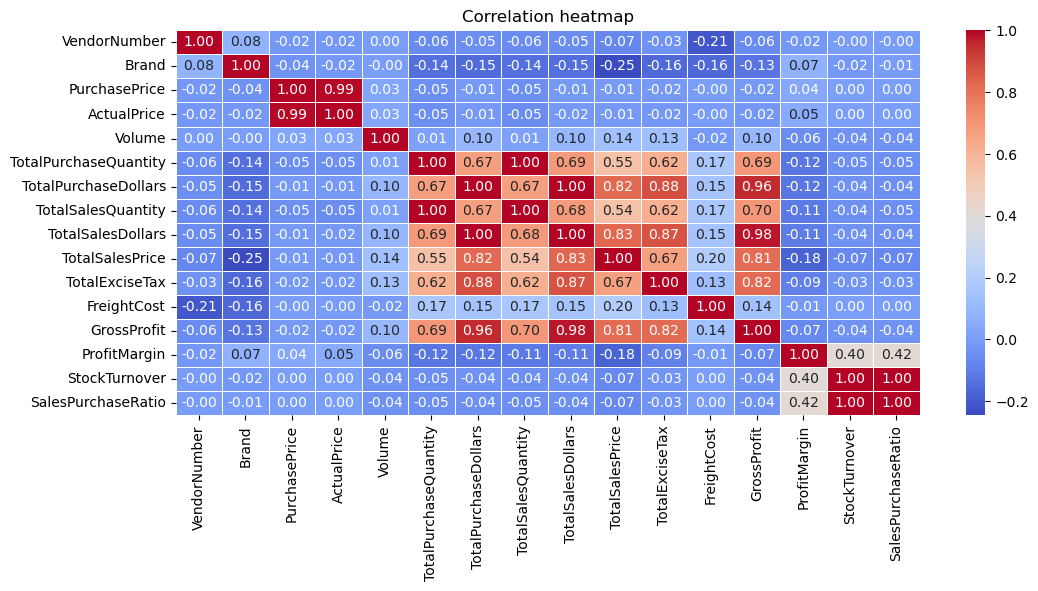

In [40]:
#Correlation heatmap
plt.figure(figsize=(12,5))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths = 0.5)
plt.title("Correlation heatmap")
plt.show()


# Correlation Insights
- PurchasePrice has weak correlations with TotalSalesDollars(-0.01) and GrossProfit (-0.02) suggesting that price variations do not significantly impact sales revenue or profit.
- Strong correlations between Total Purchase Quantity and Total Sales Quantity (0.999) confirming efficient inventory turnover.
- Negative correlation between Profit Margin and Total Sales price (-0.179) suggests that as Sales Price increases, maargins decrease, possibly due to competitive pricing pressures.
- Stock Turnover has weak negative correlations with both Gross Profit(-0.038) and Profit Margin(-0.055) indicating that faster turnover doesnot necessarily result in higher profitability.

# Data Analysis

#### Identify Brands that needs Promotional or Pricing adjustments which exhibit lower sales performance but higher profit margins

In [41]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars' : 'sum',
    'ProfitMargin' : 'mean'}).reset_index()

In [42]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [43]:
low_sales_threshold

np.float64(560.357)

In [44]:
high_margin_threshold

np.float64(65.03599999999999)

In [45]:
# filter brands with low sales but high profit margins
target_brands = brand_performance[
     (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
     (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.47
2369,Debauchery Pnt Nr,11.58,65.98
2070,Concannon Glen Ellen Wh Zin,15.95,83.45
2188,Crown Royal Apple,27.86,89.81
6237,Sauza Sprklg Wild Berry Marg,27.96,82.15
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.75
2271,Dad's Hat Rye Whiskey,538.89,81.85
57,A Bichot Clos Marechaudes,539.94,67.74
6245,Sbragia Home Ranch Merlot,549.75,66.44


In [46]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000]  #for better visualizations

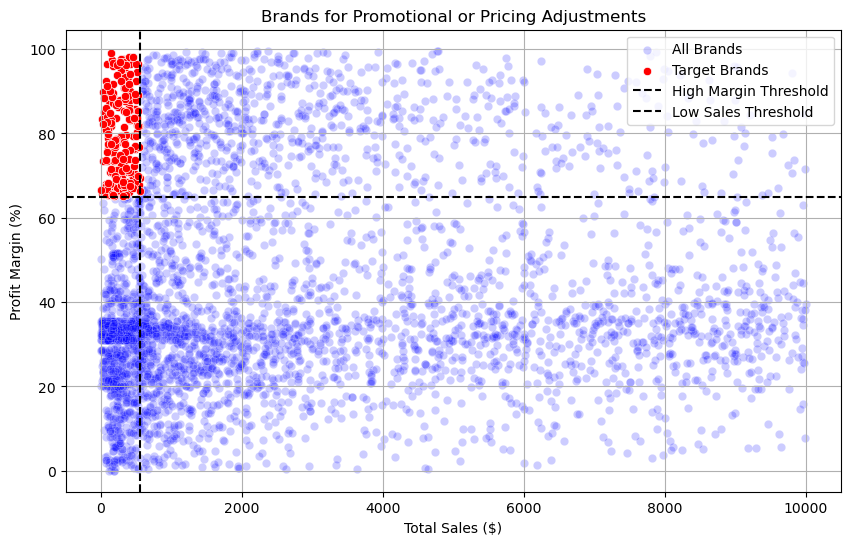

In [47]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

#### Which vendors and brands demonstrate the highest sales performance?

In [48]:
# Top vendors and brands by sales performance
top_vendors=df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands=df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [49]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [50]:
def format_dollars(value):
    if value >= 1_00_000:
        return f"{value / 1_000_000:.2f}M"
    elif value>= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [51]:
top_brands.apply(lambda x : format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: object

C:\Users\suren\AppData\Local\Temp\ipykernel_17428\2200957356.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1=sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
C:\Users\suren\AppData\Local\Temp\ipykernel_17428\2200957356.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2=sns.barplot(y=top_vendors.index.astype(str), x=top_vendors.values, palette="Reds_r")


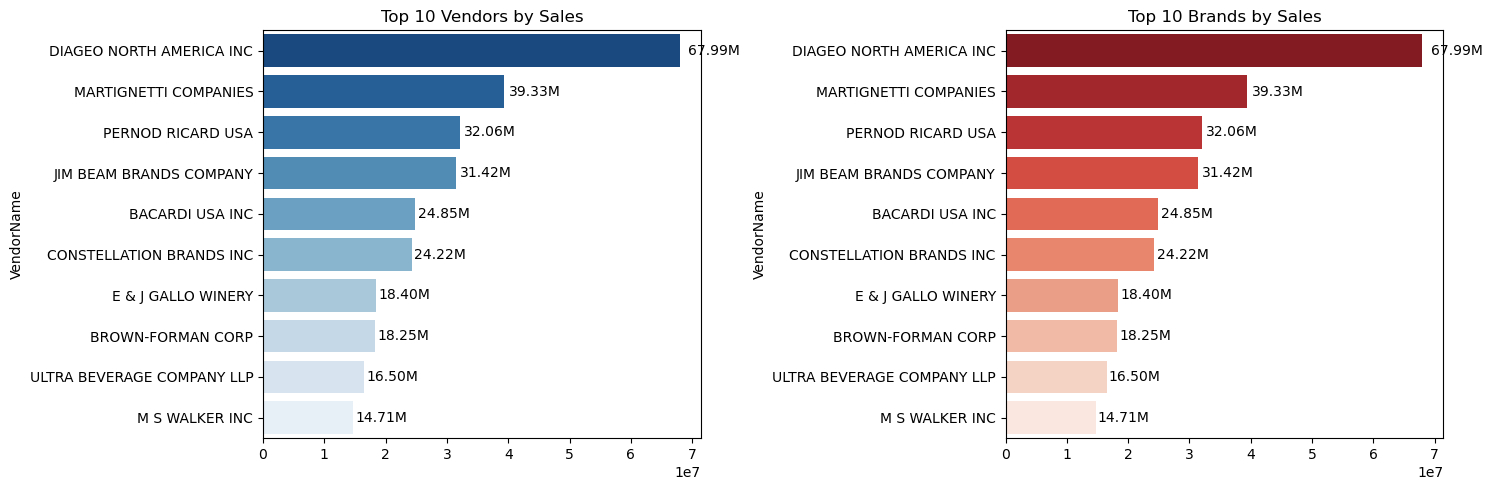

In [52]:
plt.figure(figsize=(15,5))

#plot for top vendors
plt.subplot(1,2,1)
ax1=sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
            bar.get_y() + bar.get_height() / 2,
            format_dollars(bar.get_width()),
            ha='left', va='center', fontsize=10, color='black')

#plot for top brands
plt.subplot(1,2,2)
ax2=sns.barplot(y=top_vendors.index.astype(str), x=top_vendors.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
            bar.get_y() + bar.get_height() / 2,
            format_dollars(bar.get_width()),
            ha='left', va='center', fontsize=10, color='black')
plt.tight_layout()
plt.show()


#### Which vendors contribute the most to total purchase dollars?

In [53]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()

In [54]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum()*100

In [55]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending=False),2)

In [56]:
#Display top 10 vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

C:\Users\suren\AppData\Local\Temp\ipykernel_17428\1304600609.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
C:\Users\suren\AppData\Local\Temp\ipykernel_17428\1304600609.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
C:\Users\suren\AppData\Local\Temp\ipykernel_17428\1304600609.py:5: SettingWithCopyWarning: 
A value 

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [57]:
top_vendors['PurchaseContribution%'].sum()

np.float64(65.69000000000001)

In [58]:
top_vendors['Cumulative_Contribution%']= top_vendors['PurchaseContribution%'].cumsum()
top_vendors

C:\Users\suren\AppData\Local\Temp\ipykernel_17428\1689114589.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['Cumulative_Contribution%']= top_vendors['PurchaseContribution%'].cumsum()


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


C:\Users\suren\AppData\Local\Temp\ipykernel_17428\2307892702.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendors['Cumulative_Contribution%']= top_vendors['PurchaseContribution%'].cumsum()
C:\Users\suren\AppData\Local\Temp\ipykernel_17428\2307892702.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)
C:\Users\suren\AppData\Local\Temp\ipykernel_17428\2307892702.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  a

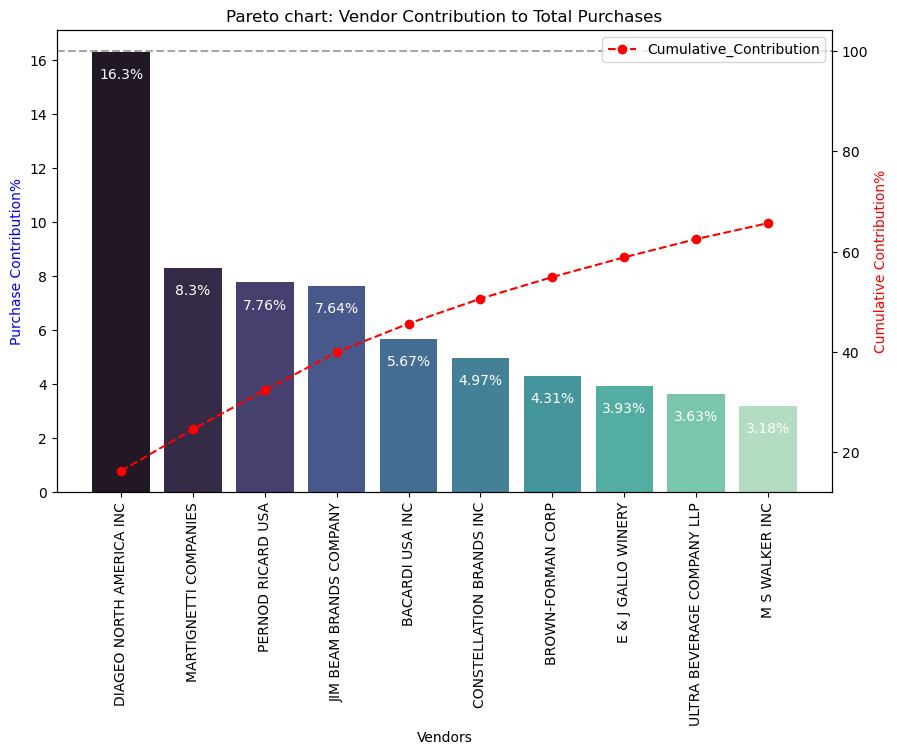

In [59]:
top_vendors['Cumulative_Contribution%']= top_vendors['PurchaseContribution%'].cumsum()

fig, ax1=plt.subplots(figsize=(10,6))

#Barplot for Purchase Contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value-1, str(value)+'%', ha='center', fontsize=10, color='white')

#Line plot for Cumulative distribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative_Contribution')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution%', color='blue')
ax2.set_ylabel('Cumulative Contribution%', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

#### How much of total procurement is dependent on the top vendors?

In [60]:
print(f"Total Purchase contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

Total Purchase contribution of top 10 vendors is 65.69 %


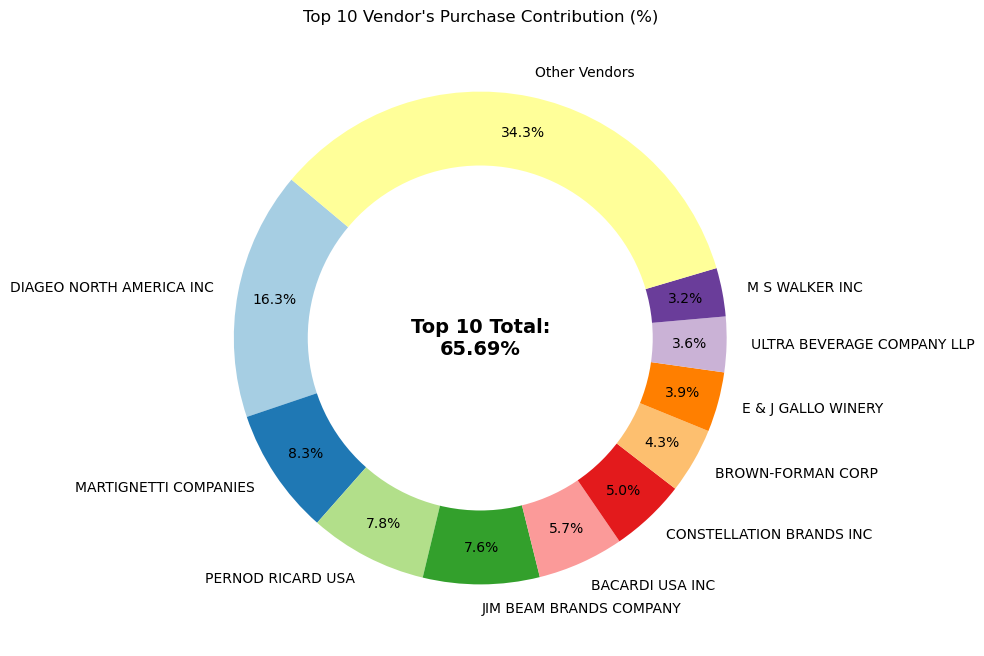

In [61]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100-total_contribution

#Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

#Donut chart
fig, ax=plt.subplots(figsize=(8,8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

#Draw a white circle in the centre to create a donut effect
centre_circle=plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

#Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()


#### Does purchasing in bulk reduce the unit price and what is the optimal purchase volume for cost savings?

In [62]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars']/ df['TotalPurchaseQuantity']

In [63]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [64]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

C:\Users\suren\AppData\Local\Temp\ipykernel_17428\1505448859.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('OrderSize')[['UnitPurchasePrice']].mean()


,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.482067
Large,10.774898


C:\Users\suren\AppData\Local\Temp\ipykernel_17428\1644235976.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")


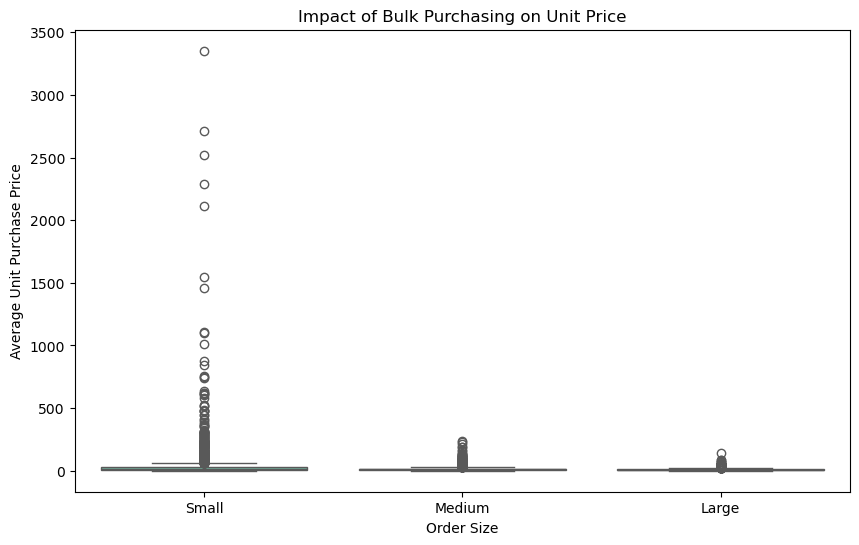

In [65]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()

- Vendors buying in bulk (large order size) get the lowest unit price ($10.78 per unit) meaning higher margins if they can manage inventory efficiently.
- The price difference between Small and Large orders is substantial(-72% reduction in unit cost).
- This suggests that bulk pricing strategies successfully encourage vendors to purchase in large volumes, leading to higher overall sales despite lower per-unit revenue.

#### Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [66]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending=True).head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.620000
HIGHLAND WINE MERCHANTS LLC,0.710000
PARK STREET IMPORTS LLC,0.750000
Circa Wines,0.755385
KLIN SPIRITS LLC,0.760000
Dunn Wine Brokers,0.767500
CENTEUR IMPORTS LLC,0.772500
SMOKY QUARTZ DISTILLERY LLC,0.780000
TAMWORTH DISTILLING,0.800000


#### How much capital is locked in unsold inventory per vendor and which vendors contribute the most of it?

In [67]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 2.71M


In [68]:
#Aggregate Vendor locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

#Sort Vendors with the highest locked capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,0.72M
46,JIM BEAM BRANDS COMPANY,0.55M
68,PERNOD RICARD USA,0.47M
116,WILLIAM GRANT & SONS INC,0.40M
30,E & J GALLO WINERY,0.23M
79,SAZERAC CO INC,0.20M
11,BROWN-FORMAN CORP,0.18M
20,CONSTELLATION BRANDS INC,0.13M
61,MOET HENNESSY USA INC,0.13M
77,REMY COINTREAU USA INC,0.12M


#### What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.

In [69]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [70]:
top_vendors = df[df["TotalSalesDollars"]>= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"]>= low_threshold]["ProfitMargin"].dropna()


In [71]:
low_vendors

3       25.54
4       38.19
5       17.00
6       73.68
7       83.08
        ...  
8560    18.82
8561    10.93
8562     7.16
8563     2.76
8564    98.85
Name: ProfitMargin, Length: 6424, dtype: float64

In [72]:
def confidence_interval(data, confidence=0.95):
    mean_val=np.mean(data)
    std_err = np.std(data, ddof=1)/ np.sqrt(len(data)) #standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error
    

Top_vendors 95% CI: (30.77, 31.65) Mean: 31.21
Low_vendors 95% CI: (37.30, 38.27) Mean: 37.78


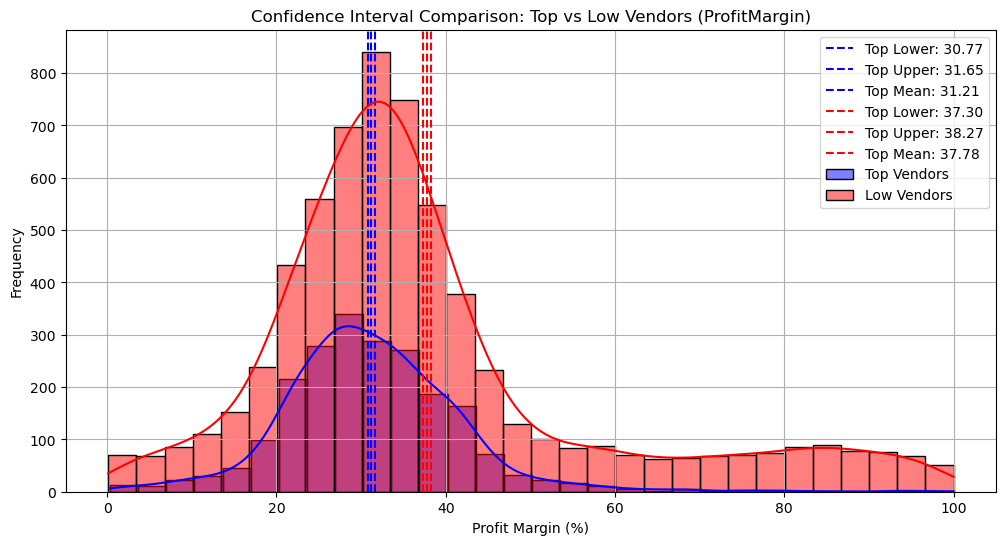

In [74]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top_vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}) Mean: {top_mean:.2f}")
print(f"Low_vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}) Mean: {low_mean:.2f}")

plt.figure(figsize=(12,6))

#Top vendors plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="--", label=f"Top Mean: {top_mean:.2f}")

#Low vendors plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Top Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Top Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="--", label=f"Top Mean: {low_mean:.2f}")

#Finalize Plot
plt.title("Confidence Interval Comparison: Top vs Low Vendors (ProfitMargin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


- The confidence interval for low-performing vendors (37.30% to 38.27%) is significantly higher than that of top-performing vendors (30.77% to 31.65).
- This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.
- For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimizations or bundling strategies.
- For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

#### Is there a significant difference in profit margins between top-performing and low-performing vendors?
Hypothesis:
- Ho (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

- H1 (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [76]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"]>= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"]>= low_threshold]["ProfitMargin"].dropna()

# Perform two-sample T-test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject Ho: There is significant difference in profit margins between top and low-performing vendors")
else:
    print("Fail to reject Ho: No significant difference in profit margins.")


T-Statistic: -19.6601, P-Value: 0.0000
Reject Ho: There is significant difference in profit margins between top and low-performing vendors
